In [26]:
import pandas as pd

In [27]:
df = pd.read_csv("db_delays.csv")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 126 rows × 18 columns


,scraped_at,station_eva,station_name,trip_id,train_name,train_type,planned_departure,actual_departure,dep_delay_min,planned_arrival,actual_arrival,arr_delay_min,planned_platform,actual_platform,planned_path,changed_path,cancelled,messages
0,2026-05-25T22:03:02Z,8000261,München Hbf,1596813174957884490-2605252236-14,RB 59464,RB,NaN,NaN,NaN,2026-05-26T00:26,2026-05-26T00:32,6.0,27.0,NaN,NaN,NaN,False,NaN
1,2026-05-25T22:03:02Z,8000261,München Hbf,4285486104745153047-2605260012-1,S 8290,S,2026-05-26T00:12,2026-05-26T00:12,0.0,NaN,NaN,NaN,27.0,NaN,München-Obermenzing|München-Untermenzing|Münch...,NaN,False,NaN
2,2026-05-25T22:03:02Z,8000261,München Hbf,2753715244443311994-2605252352-10,S 22279,S,NaN,NaN,NaN,2026-05-26T00:31,2026-05-26T00:29,-2.0,29.0,NaN,NaN,NaN,False,NaN
3,2026-05-25T22:03:02Z,8000261,München Hbf,3472286637044439164-2605252228-12,RE 4091,RE,NaN,NaN,NaN,2026-05-26T00:53,2026-05-26T00:56,3.0,23.0,NaN,NaN,NaN,False,NaN
4,2026-05-25T22:03:02Z,8000261,München Hbf,1436814623556898928-2605260017-10,S 8261,S,NaN,NaN,NaN,2026-05-26T00:51,2026-05-26T00:51,0.0,29.0,NaN,NaN,NaN,False,NaN


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (10, 5)

# ── Reproducibility ─────────────────────────────────────────────────────────
np.random.seed(42)

print("All libraries loaded ✓")

All libraries loaded ✓


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   scraped_at         126 non-null    object 
 1   station_eva        126 non-null    int64  
 2   station_name       126 non-null    object 
 3   trip_id            126 non-null    object 
 4   train_name         126 non-null    object 
 5   train_type         126 non-null    object 
 6   planned_departure  63 non-null     object 
 7   actual_departure   63 non-null     object 
 8   dep_delay_min      45 non-null     float64
 9   planned_arrival    85 non-null     object 
 10  actual_arrival     85 non-null     object 
 11  arr_delay_min      74 non-null     float64
 12  planned_platform   117 non-null    float64
 13  actual_platform    6 non-null      object 
 14  planned_path       63 non-null     object 
 15  changed_path       3 non-null      object 
 16  cancelled          126 non

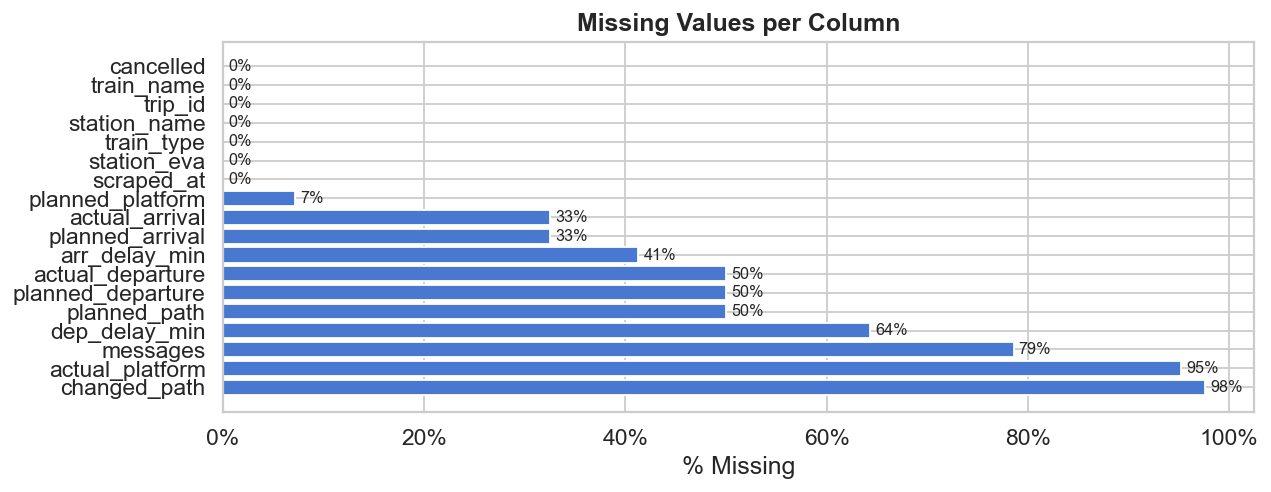


💡 Takeaway: actual_platform (95% missing) and messages (78%) are too sparse for analysis.
   dep_delay_min is 64% missing because many rows are arrivals-only — not a data error!


In [30]:
missing = df.isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing.values, color=sns.color_palette("muted")[0])
ax.set_xlabel("% Missing")
ax.set_title("Missing Values per Column", fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Annotate bars with %
for bar, val in zip(bars, missing.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("01_missing_values.png", bbox_inches="tight")
plt.show()

print("\n💡 Takeaway: actual_platform (95% missing) and messages (78%) are too sparse for analysis.")
print("   dep_delay_min is 64% missing because many rows are arrivals-only — not a data error!")


In [31]:
datetime_cols = ["scraped_at", "planned_departure", "actual_departure",
                 "planned_arrival", "actual_arrival"]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

print("Parsed datetime columns:")
df[datetime_cols].dtypes

Parsed datetime columns:


scraped_at           datetime64[ns, UTC]
planned_departure    datetime64[ns, UTC]
actual_departure     datetime64[ns, UTC]
planned_arrival      datetime64[ns, UTC]
actual_arrival       datetime64[ns, UTC]
dtype: object

In [32]:
def record_type(row):
    has_dep = pd.notna(row["planned_departure"])
    has_arr = pd.notna(row["planned_arrival"])
    if has_dep and has_arr:
        return "both"
    elif has_dep:
        return "departure_only"
    else:
        return "arrival_only"

df["record_type"] = df.apply(record_type, axis=1)
df["record_type"].value_counts()

record_type
arrival_only      63
departure_only    41
both              22
Name: count, dtype: int64

In [33]:
# Is the train late? (more than 5 min is the DB official threshold)
df["dep_is_late"] = df["dep_delay_min"] > 5
df["arr_is_late"] = df["arr_delay_min"] > 5

# Severity bucket for arrival delay
def delay_bucket(mins):
    if pd.isna(mins):      return np.nan
    if mins <= 0:          return "On time / Early"
    if mins <= 5:          return "Minor (1–5 min)"
    if mins <= 15:         return "Moderate (6–15 min)"
    if mins <= 30:         return "Significant (16–30 min)"
    return                        "Severe (>30 min)"

df["arr_delay_bucket"] = df["arr_delay_min"].apply(delay_bucket)

# Number of stops on planned route
df["n_stops"] = df["planned_path"].apply(
    lambda x: len(x.split("|")) if pd.notna(x) else np.nan
)

print("New columns added:")
print(df[["dep_is_late", "arr_is_late", "arr_delay_bucket", "n_stops"]].head(8))


New columns added:
   dep_is_late  arr_is_late     arr_delay_bucket  n_stops
0        False         True  Moderate (6–15 min)      NaN
1        False        False                  NaN      9.0
2        False        False      On time / Early      NaN
3        False        False      Minor (1–5 min)      NaN
4        False        False      On time / Early      NaN
5         True        False                  NaN     22.0
6        False        False      On time / Early      NaN
7        False        False      On time / Early      NaN


In [34]:
print(f"Total records   : {len(df)}")
print(f"Stations covered: {df['station_name'].nunique()} → {df['station_name'].unique().tolist()}")
print(f"Train types     : {sorted(df['train_type'].unique().tolist())}")
print(f"Cancelled trains: {df['cancelled'].sum()}")
print(f"Arrivals with delay info : {df['arr_delay_min'].notna().sum()}")
print(f"Departures with delay info: {df['dep_delay_min'].notna().sum()}")


Total records   : 126
Stations covered: 6 → ['München Hbf', 'Frankfurt(Main)Hbf', 'Berlin Hbf', 'Düsseldorf Hbf', 'Hamburg Hbf', 'Augsburg Hbf']
Train types     : ['ALX', 'ARV', 'Bus', 'ERB', 'HLB', 'ICE', 'NX', 'OE', 'RB', 'RE', 'S', 'STN', 'VIA']
Cancelled trains: 2
Arrivals with delay info : 74
Departures with delay info: 45


In [35]:
print("=== ARRIVAL DELAY (minutes) ===")
print(df["arr_delay_min"].describe().round(2))
print()
print("=== DEPARTURE DELAY (minutes) ===")
print(df["dep_delay_min"].describe().round(2))

=== ARRIVAL DELAY (minutes) ===
count     74.00
mean       5.68
std       16.18
min      -10.00
25%        0.00
50%        0.00
75%        4.00
max      120.00
Name: arr_delay_min, dtype: float64

=== DEPARTURE DELAY (minutes) ===
count    45.00
mean      4.44
std      10.23
min       0.00
25%       0.00
50%       0.00
75%       3.00
max      45.00
Name: dep_delay_min, dtype: float64


In [36]:
# Only use rows that actually have arrival delay info
arr = df[df["arr_delay_min"].notna()].copy()

ontime = (
    arr.groupby("train_type")
    .apply(lambda g: (g["arr_delay_min"] <= 5).mean() * 100, include_groups=False)
    .reset_index()
    .rename(columns={0: "on_time_pct"})
    .sort_values("on_time_pct", ascending=False)
)

print(ontime.to_string(index=False))

train_type  on_time_pct
       ALX   100.000000
       ERB   100.000000
       STN   100.000000
        OE   100.000000
        RE    93.750000
         S    90.000000
       ARV    88.888889
        RB    85.714286
       HLB    66.666667
       ICE    58.823529
        NX    40.000000
       VIA     0.000000


In [37]:
station_delay = (
    arr.groupby("station_name")["arr_delay_min"]
    .agg(["mean", "median", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
    .rename(columns={"mean": "Mean delay (min)", "median": "Median delay (min)", "count": "N"})
)
print(station_delay)


                    Mean delay (min)  Median delay (min)   N
station_name                                                
München Hbf                    13.92                 1.5  12
Düsseldorf Hbf                  6.17                 2.0  18
Berlin Hbf                      6.10                 1.0  10
Augsburg Hbf                    3.75                 0.0   4
Hamburg Hbf                     3.60                 0.0  15
Frankfurt(Main)Hbf              0.80                 0.0  15


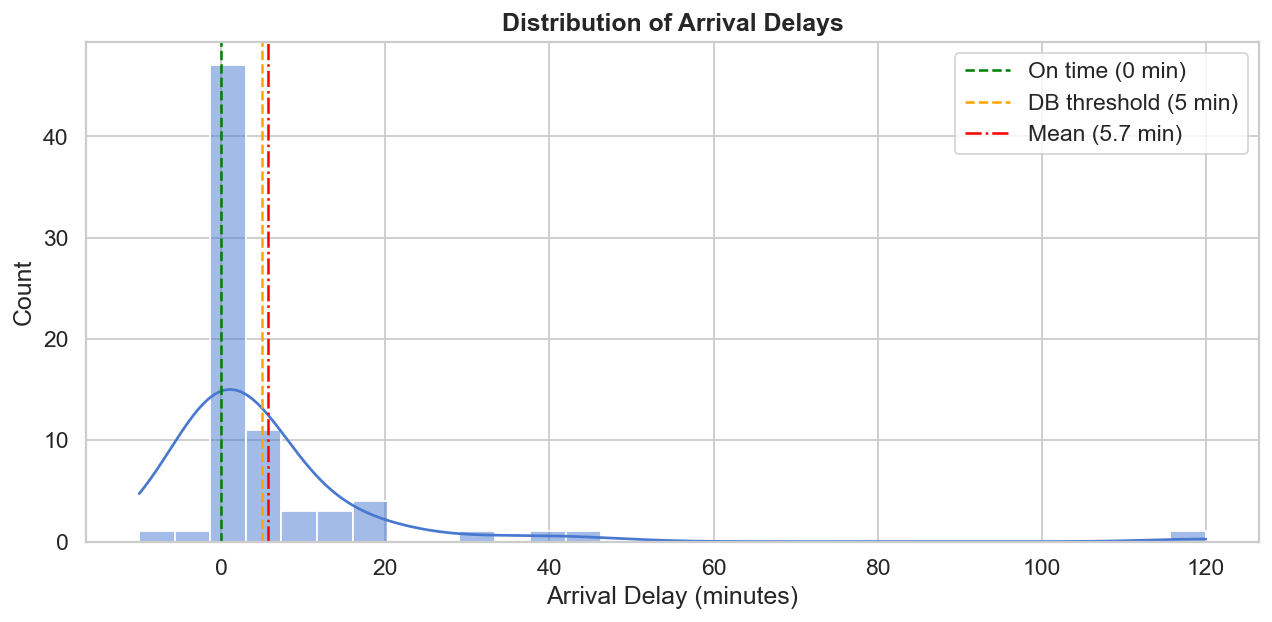


💡 Right-skewed distribution: most trains are on time but a few outliers pull the mean up.


In [38]:
fig, ax = plt.subplots()

sns.histplot(
    arr["arr_delay_min"],
    bins=30,
    kde=True,
    color=sns.color_palette("muted")[0],
    ax=ax
)

ax.axvline(0, color="green", linestyle="--", linewidth=1.4, label="On time (0 min)")
ax.axvline(5, color="orange", linestyle="--", linewidth=1.4, label="DB threshold (5 min)")
ax.axvline(arr["arr_delay_min"].mean(), color="red", linestyle="-.", linewidth=1.4,
           label=f'Mean ({arr["arr_delay_min"].mean():.1f} min)')

ax.set_xlabel("Arrival Delay (minutes)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Arrival Delays", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("02_delay_distribution.png", bbox_inches="tight")
plt.show()

print("\n💡 Right-skewed distribution: most trains are on time but a few outliers pull the mean up.")


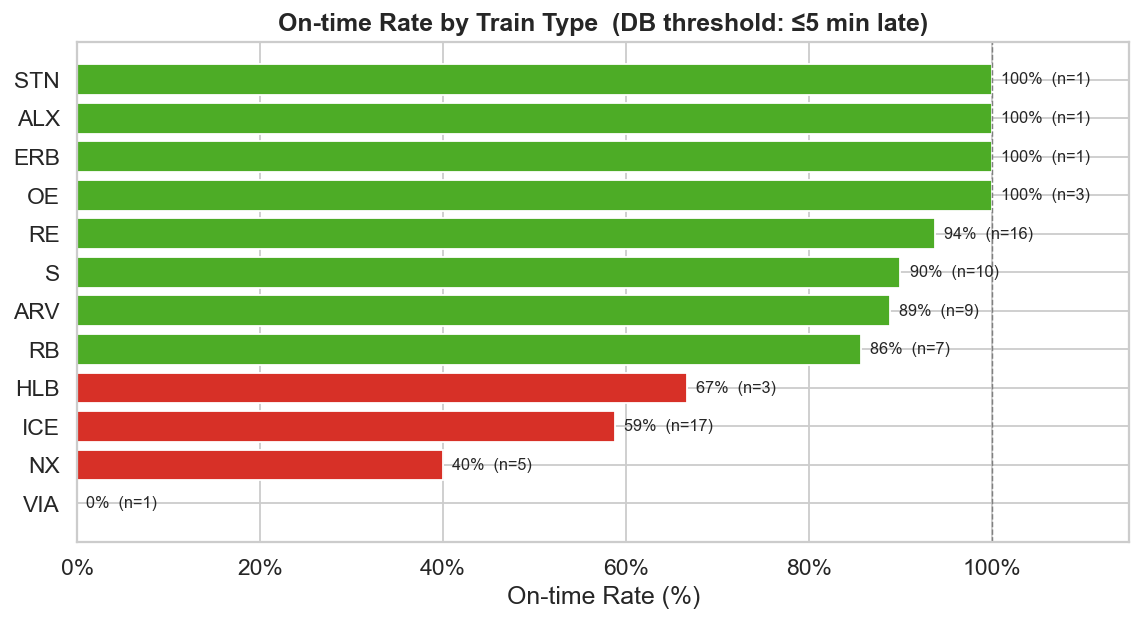

In [39]:
# Rebuild ontime with sample size info for labelling
ontime_full = (
    arr.groupby("train_type")
    .agg(
        on_time_pct=("arr_delay_min", lambda x: (x <= 5).mean() * 100),
        n=("arr_delay_min", "count")
    )
    .reset_index()
    .sort_values("on_time_pct")
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d73027" if v < 70 else "#fee090" if v < 85 else "#4dac26"
          for v in ontime_full["on_time_pct"]]

bars = ax.barh(ontime_full["train_type"], ontime_full["on_time_pct"], color=colors)
ax.axvline(100, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("On-time Rate (%)")
ax.set_title("On-time Rate by Train Type  (DB threshold: ≤5 min late)", fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 115)

for bar, row in zip(bars, ontime_full.itertuples()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{row.on_time_pct:.0f}%  (n={row.n})", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("03_ontime_by_type.png", bbox_inches="tight")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_43048\3172539542.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


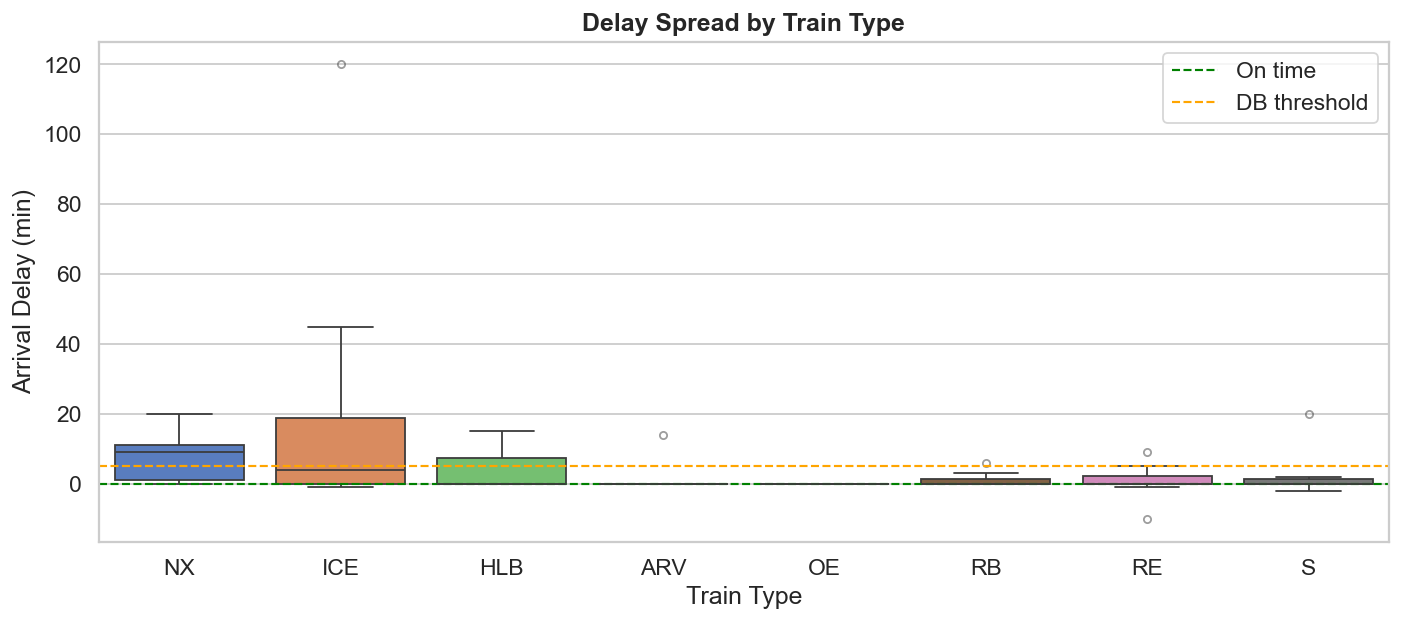


💡 Dots above the whiskers are outliers — individual trains with unusually large delays.


In [40]:
# Filter to types with at least 3 records so the box is meaningful
type_counts = arr["train_type"].value_counts()
valid_types = type_counts[type_counts >= 3].index
arr_filtered = arr[arr["train_type"].isin(valid_types)]

order = (arr_filtered.groupby("train_type")["arr_delay_min"]
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=arr_filtered,
    x="train_type", y="arr_delay_min",
    order=order,
    palette="muted",
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
    ax=ax
)

ax.axhline(0, color="green", linestyle="--", linewidth=1.2, label="On time")
ax.axhline(5, color="orange", linestyle="--", linewidth=1.2, label="DB threshold")
ax.set_xlabel("Train Type")
ax.set_ylabel("Arrival Delay (min)")
ax.set_title("Delay Spread by Train Type", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("04_boxplot_by_type.png", bbox_inches="tight")
plt.show()
print("\n💡 Dots above the whiskers are outliers — individual trains with unusually large delays.")


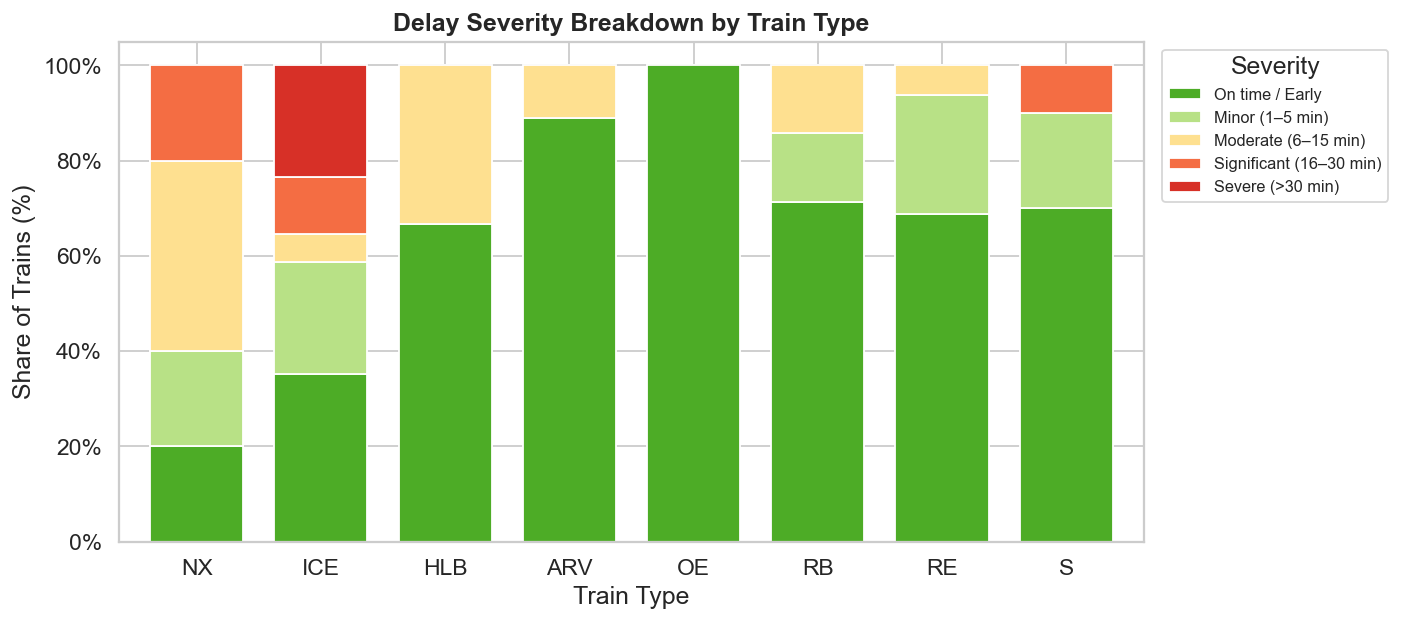

In [41]:
bucket_order = ["On time / Early", "Minor (1–5 min)",
                "Moderate (6–15 min)", "Significant (16–30 min)", "Severe (>30 min)"]
palette = ["#4dac26", "#b8e186", "#fee090", "#f46d43", "#d73027"]

pivot = (
    arr_filtered.groupby(["train_type", "arr_delay_bucket"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=bucket_order, fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.loc[order]  # same order as box plot

fig, ax = plt.subplots(figsize=(11, 5))
pivot_pct.plot(kind="bar", stacked=True, color=palette, ax=ax, width=0.75)

ax.set_xlabel("Train Type")
ax.set_ylabel("Share of Trains (%)")
ax.set_title("Delay Severity Breakdown by Train Type", fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="Severity", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("05_severity_stacked.png", bbox_inches="tight")
plt.show()


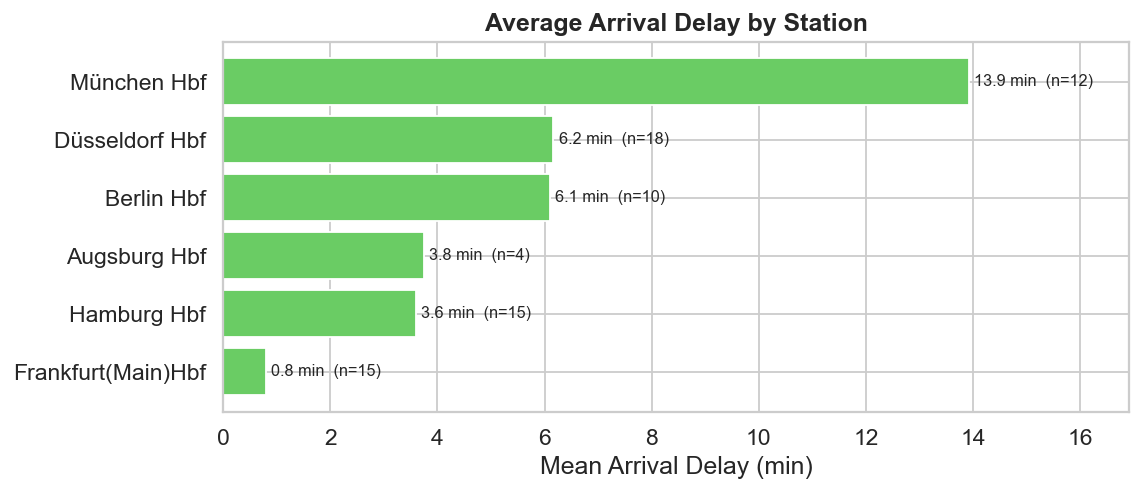

In [42]:
station_mean = (
    arr.groupby("station_name")["arr_delay_min"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(station_mean["station_name"], station_mean["mean"],
               color=sns.color_palette("muted")[2])

for bar, row in zip(bars, station_mean.itertuples()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{row.mean:.1f} min  (n={row.count})", va="center", fontsize=9)

ax.set_xlabel("Mean Arrival Delay (min)")
ax.set_title("Average Arrival Delay by Station", fontweight="bold")
ax.set_xlim(0, station_mean["mean"].max() + 3)

plt.tight_layout()
plt.savefig("07_delay_by_station.png", bbox_inches="tight")
plt.show()


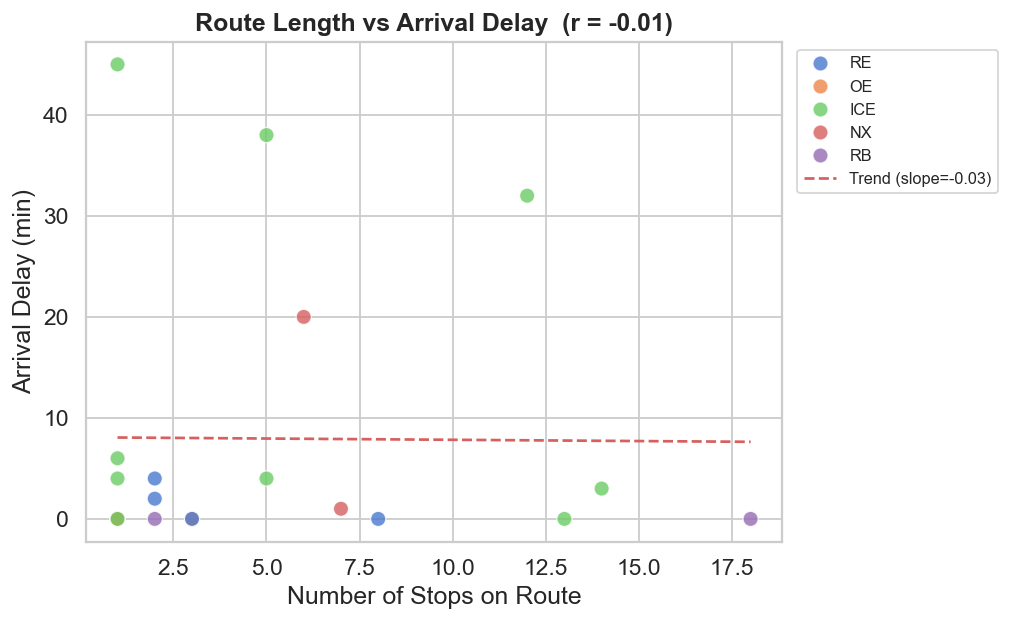

In [43]:
route_delay = arr[arr["n_stops"].notna()].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=route_delay,
    x="n_stops", y="arr_delay_min",
    hue="train_type", s=70, alpha=0.8, ax=ax
)

# Add a linear trend line
m, b = np.polyfit(route_delay["n_stops"], route_delay["arr_delay_min"], 1)
x_line = np.linspace(route_delay["n_stops"].min(), route_delay["n_stops"].max(), 100)
ax.plot(x_line, m * x_line + b, "r--", linewidth=1.5, label=f"Trend (slope={m:.2f})")

corr_route = route_delay["n_stops"].corr(route_delay["arr_delay_min"])
ax.set_xlabel("Number of Stops on Route")
ax.set_ylabel("Arrival Delay (min)")
ax.set_title(f"Route Length vs Arrival Delay  (r = {corr_route:.2f})", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("08_route_vs_delay.png", bbox_inches="tight")
plt.show()


In [44]:
arr_mean = arr["arr_delay_min"].mean()
arr_median = arr["arr_delay_min"].median()
arr_ontime_pct = (arr["arr_delay_min"] <= 5).mean() * 100
worst_type = ontime.sort_values("on_time_pct").iloc[0]
best_type  = ontime.sort_values("on_time_pct").iloc[-1]
worst_station = station_delay.sort_values("Mean delay (min)", ascending=False).index[0]

print("=" * 60)
print("          ANALYSIS SUMMARY — DB DELAYS DATASET")
print("=" * 60)
print(f"  Snapshot date      : May 25–26, 2026")
print(f"  Stations analysed  : {df['station_name'].nunique()}")
print(f"  Total records      : {len(df)}")
print(f"  Cancelled trains   : {df['cancelled'].sum()}")
print()
print(f"  Mean arrival delay : {arr_mean:.1f} min")
print(f"  Median arr. delay  : {arr_median:.0f} min (half of trains are at/below this)")
print(f"  Overall on-time %  : {arr_ontime_pct:.1f}%")
print()
print(f"  Best punctuality   : {best_type['train_type']}  ({best_type['on_time_pct']:.0f}% on time)")
print(f"  Worst punctuality  : {worst_type['train_type']}  ({worst_type['on_time_pct']:.0f}% on time)")
print(f"  Most delayed stn   : {worst_station}")
print()
print("  Charts saved: 01–08 PNG files in working directory")
print("=" * 60)

          ANALYSIS SUMMARY — DB DELAYS DATASET
  Snapshot date      : May 25–26, 2026
  Stations analysed  : 6
  Total records      : 126
  Cancelled trains   : 2

  Mean arrival delay : 5.7 min
  Median arr. delay  : 0 min (half of trains are at/below this)
  Overall on-time %  : 78.4%

  Best punctuality   : OE  (100% on time)
  Worst punctuality  : VIA  (0% on time)
  Most delayed stn   : München Hbf

  Charts saved: 01–08 PNG files in working directory


In [45]:
df

,scraped_at,station_eva,station_name,trip_id,train_name,train_type,planned_departure,actual_departure,dep_delay_min,planned_arrival,...,actual_platform,planned_path,changed_path,cancelled,messages,record_type,dep_is_late,arr_is_late,arr_delay_bucket,n_stops
0,2026-05-25 22:03:02+00:00,8000261,München Hbf,1596813174957884490-2605252236-14,RB 59464,RB,NaT,NaT,NaN,2026-05-26 00:26:00+00:00,...,NaN,NaN,NaN,False,NaN,arrival_only,False,True,Moderate (6–15 min),NaN
1,2026-05-25 22:03:02+00:00,8000261,München Hbf,4285486104745153047-2605260012-1,S 8290,S,2026-05-26 00:12:00+00:00,2026-05-26 00:12:00+00:00,0.0,NaT,...,NaN,München-Obermenzing|München-Untermenzing|Münch...,NaN,False,NaN,departure_only,False,False,NaN,9.0
2,2026-05-25 22:03:02+00:00,8000261,München Hbf,2753715244443311994-2605252352-10,S 22279,S,NaT,NaT,NaN,2026-05-26 00:31:00+00:00,...,NaN,NaN,NaN,False,NaN,arrival_only,False,False,On time / Early,NaN
3,2026-05-25 22:03:02+00:00,8000261,München Hbf,3472286637044439164-2605252228-12,RE 4091,RE,NaT,NaT,NaN,2026-05-26 00:53:00+00:00,...,NaN,NaN,NaN,False,NaN,arrival_only,False,False,Minor (1–5 min),NaN
4,2026-05-25 22:03:02+00:00,8000261,München Hbf,1436814623556898928-2605260017-10,S 8261,S,NaT,NaT,NaN,2026-05-26 00:51:00+00:00,...,NaN,NaN,NaN,False,NaN,arrival_only,False,False,On time / Early,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2026-05-25 22:03:02+00:00,8000068,Augsburg Hbf,5391302266099657590-2605252326-19,RB 15338,RB,2026-05-26 00:30:00+00:00,2026-05-26 00:30:00+00:00,0.0,2026-05-26 00:26:00+00:00,...,NaN,Langen(Hess)|Frankfurt(Main)Hbf,NaN,False,NaN,both,False,False,On time / Early,2.0
122,2026-05-25 22:03:02+00:00,8000068,Augsburg Hbf,-7982581853949141333-2605260040-1,VIA 25231,VIA,2026-05-26 00:40:00+00:00,2026-05-26 00:40:00+00:00,NaN,NaT,...,NaN,Darmstadt Nord|Darmstadt Ost|Darmstadt TU-Lich...,NaN,False,NaN,departure_only,False,False,NaN,8.0
123,2026-05-25 22:03:02+00:00,8000068,Augsburg Hbf,-180321424141978281-2605260006-3,RB 15341,RB,2026-05-26 00:30:00+00:00,2026-05-26 00:30:00+00:00,0.0,2026-05-26 00:25:00+00:00,...,NaN,Darmstadt Süd|Darmstadt-Eberstadt|Bickenbach(B...,NaN,False,NaN,both,False,False,On time / Early,18.0
124,2026-05-25 22:03:02+00:00,8000068,Augsburg Hbf,2403516544946102150-2605252342-8,HLB 24539,HLB,NaT,NaT,NaN,2026-05-26 00:31:00+00:00,...,NaN,NaN,NaN,False,NaN,arrival_only,False,True,Moderate (6–15 min),NaN
